# Exploratory Data Analysis: Store and Product Daily Sales

Investigate long-term trends, seasonal patterns (componenets) and how sales differ between stores and products.

Data: Daily sales from 2010 to 2019, with columns `Date`, `store`, `product` and
`number_sold`. There are 7 stores and 10 products, so 70 store x product pairs. The training
data ranges from 2010 to 2018, and test data is 2019.

## 1. Setup

In [26]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



raw = Path("../data/raw")
processed = Path("../data/processed")
figures = Path("../figures")

raw.mkdir(parents=True, exist_ok=True)
processed.mkdir(parents=True, exist_ok=True)
figures.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)


def save(fig, name):
    """Save figure  to use later in the dashboard."""
    fig.savefig(figures/f"{name}.png", bbox_inches="tight", dpi=150)
    return fig

## 2. Load and validate


In [27]:
df_train = pd.read_csv(raw/"train.csv", parse_dates=["Date"])
df_test = pd.read_csv(raw/"test.csv", parse_dates=["Date"])

print(f"train: {df_train.shape[0]:,} rows")
print(f"Date range: {df_train.Date.min():%Y-%m-%d} -> {df_train.Date.max():%Y-%m-%d}")


print(f"test:{df_test.shape[0]:,} rows")
print(f"Date range: {df_test.Date.min():%Y-%m-%d} -> {df_test.Date.max():%Y-%m-%d}")

df_train.head()

train: 230,090 rows
Date range: 2010-01-01 -> 2018-12-31
test:25,550 rows
Date range: 2019-01-01 -> 2019-12-31


,Date,store,product,number_sold
0,2010-01-01,0,0,801
1,2010-01-02,0,0,810
2,2010-01-03,0,0,818
3,2010-01-04,0,0,796
4,2010-01-05,0,0,808


In [28]:
df_test.head()

,Date,store,product,number_sold
0,2019-01-01,0,0,845
1,2019-01-02,0,0,851
2,2019-01-03,0,0,840
3,2019-01-04,0,0,842
4,2019-01-05,0,0,845


In [29]:
def check_data(df, name):
    n_days = df.Date.nunique()
    store_product_combinations = df.groupby(["store", "product"]).ngroups
    expected = n_days * store_product_combinations      # 3287 * 70 number of days times store x product combinations
    span = (df.Date.max() - df.Date.min()).days + 1
    return {
        "dataset": name,
        "rows": len(df),
        "unique_dates": n_days,
        "calendar_days_in_date_range": span, # Meeaning no date is missing in the range
        "(store x product)": store_product_combinations,
        "rows_if_complete": expected,
        "null_values": int(df.isna().sum().sum()),
        "duplicate_keys": int(df.duplicated(["Date", "store", "product"]).sum()),  # check whether the combination of date, store and product is unique or duplicated
        "negative_or_zero_sales": int((df.number_sold <= 0).sum()),
    }

pd.DataFrame([check_data(df_train, "train"), check_data(df_test, "test")]).set_index("dataset")

,rows,unique_dates,calendar_days_in_date_range,(store x product),rows_if_complete,null_values,duplicate_keys,negative_or_zero_sales
dataset,,,,,,,,
train,230090,3287,3287,70,230090,0,0,0
test,25550,365,365,70,25550,0,0,0


### Finding 1: The data is complete and clean

Each of the 70 store-product pairs has a value for every day: 3,287 days in the training data and
365 days in the test data. There are no missing values, no duplicate rows, no zero or negative sales
and no gaps in the dates.

So we do not need to fill in missing values or fix the dates before we start modelling.

## 3. Summary statistics for each store-product pair

In [30]:
df_train.number_sold.describe().to_frame("number_sold")

,number_sold
count,230090.000000
mean,780.926107
std,204.096737
min,238.000000
25%,722.000000
50%,835.000000
75%,914.000000
max,1205.000000


Calculate some statistics for each store x product pair, rather than general ones.

In [31]:
train_copy = df_train.copy()
train_copy["year"] = train_copy.Date.dt.year
train_copy["month"] = train_copy.Date.dt.month
train_copy["day_of_week"] = train_copy.Date.dt.dayofweek

pair_statistics = (train_copy.groupby(["store", "product"]).number_sold.
                   agg(
                       mean="mean", 
                       std="std", 
                       min="min", 
                       q25=lambda s: s.quantile(.25), 
                       median="median",
                       q75=lambda s: s.quantile(.75), 
                       max="max"
                       )
                    )
pair_statistics["variation_coefficient_pct"] = pair_statistics["std"] / pair_statistics["mean"] * 100          

pair_statistics.round(3).head(10)

mean     std  min    q25  median    q75   max  variation_coefficient_pct
store product                                                                             
0     0        828.677  38.403  747  795.0   828.0  863.0   921                      4.634
      1        738.379  37.139  641  712.0   736.0  761.0   884                      5.030
      2        940.479  51.138  814  895.0   941.0  986.0  1055                      5.437
      3        851.494  37.269  750  822.0   851.0  883.0   938                      4.377
      4        907.429  44.673  808  871.0   907.0  943.0  1020                      4.923
      5        912.764  19.663  841  902.0   914.0  926.0   976                      2.154
      6        871.705  21.485  809  855.0   872.0  888.0   938                      2.465
      7        951.706  46.035  815  918.5   951.0  989.0  1066                      4.837
      8        644.730  36.342  546  627.0   640.0  654.0   773                      5.637
      9        827.851  32.286  735  803.0   828.0  853.0   913                      3.900

Mean sales per year for each store x product.

In [32]:
yearly = train_copy.pivot_table(index=["store", "product"], columns="year",
                                values="number_sold", aggfunc="mean")
yearly.head(15)

year                 2010        2011        2012        2013        2014        2015        2016        2017  \
store product                                                                                                   
0     0        814.205479  823.178082  828.950820  830.476712  830.756164  829.824658  830.292350  832.416438   
      1        800.210959  759.158904  738.311475  731.254795  731.923288  734.830137  733.289617  721.589041   
      2        907.832877  929.120548  940.267760  944.419178  943.791781  942.693151  942.795082  949.191781   
      3        822.093151  841.835616  851.538251  853.961644  854.304110  853.676712  853.576503  859.304110   
      4        893.736986  902.243836  906.836066  909.049315  910.046575  908.364384  908.336066  911.383562   
      5        879.567123  902.178082  912.994536  916.857534  916.073973  914.980822  915.459016  920.942466   
      6        882.926027  874.717808  872.087432  871.419178  870.210959  870.936986  870.519126  869.019178   
      7        900.295890  934.208219  951.647541  958.452055  957.452055  955.065753  954.262295  966.060274   
      8        722.197260  670.756164  644.625683  635.060274  636.980822  640.128767  638.598361  624.693151   
      9        804.367123  819.526027  827.418033  830.112329  830.356164  829.591781  829.502732  834.117808   
1     0        691.734247  695.830137  688.398907  673.473973  656.668493  640.558904  631.852459  632.528767   
      1        802.153425  806.353425  796.114754  778.701370  758.509589  738.068493  726.666667  727.926027   
      2        687.758904  681.065753  692.773224  717.295890  744.572603  771.180822  786.191257  784.526027   
      3        673.265753  675.819178  671.459016  665.739726  657.802740  651.249315  648.292350  648.389041   
      4        744.005479  747.008219  742.513661  729.328767  716.895890  704.471233  697.672131  698.054795   

year                 2018  
store product              
0     0        837.986301  
      1        694.860274  
      2        964.197260  
      3        873.147945  
      4        916.865753  
      5        935.810959  
      6        863.512329  
      7        987.901370  
      8        589.542466  
      9        845.663014  
1     0        647.304110  
      1        747.454795  
      2        758.942466  
      3        654.553425  
      4        709.747945

In [33]:
pair_statistics["growth_2010_2018_pct"] = (yearly[2018] / yearly[2010] - 1) * 100
pair_statistics

mean        std  min    q25  median    q75   max  variation_coefficient_pct  growth_2010_2018_pct
store product                                                                                                         
0     0        828.676909  38.402983  747  795.0   828.0  863.0   921                   4.634253              2.920740
      1        738.379373  37.138921  641  712.0   736.0  761.0   884                   5.029788            -13.165364
      2        940.479465  51.137524  814  895.0   941.0  986.0  1055                   5.437389              6.208674
      3        851.493763  37.269240  750  822.0   851.0  883.0   938                   4.376925              6.210342
      4        907.429267  44.673242  808  871.0   907.0  943.0  1020                   4.923055              2.587872
...                   ...        ...  ...    ...     ...    ...   ...                        ...                   ...
6     5        872.162762  25.773747  811  850.0   872.0  894.0   937                   2.955153             -1.364020
      6        950.451171  23.057999  890  932.0   950.0  969.0  1010                   2.426006              2.018240
      7        850.695163  20.824810  798  835.0   849.0  865.0   918                   2.447976             -5.648287
      8        811.315789  37.842822  710  777.5   811.0  845.0   899                   4.664376              2.680615
      9        889.647703  24.672376  811  872.0   890.0  908.0   963                   2.773275              2.911109

[70 rows x 9 columns]

In [34]:
month_index = train_copy.pivot_table(
    index=["store", "product"], 
    columns="month",
    values="number_sold", 
    aggfunc="mean"
    )     # average number of sales per month for each store-product combination
month_index = month_index.div(month_index.mean(axis=1), axis=0) * 100  # normalize by the mean 

pair_statistics["annual_difference_pct"] = month_index.max(axis=1) - month_index.min(axis=1) # difference between peak month and trough month
pair_statistics["peak_month"] = month_index.idxmax(axis=1)
pair_statistics

mean        std  min    q25  median    q75   max  variation_coefficient_pct  \
store product                                                                                      
0     0        828.676909  38.402983  747  795.0   828.0  863.0   921                   4.634253   
      1        738.379373  37.138921  641  712.0   736.0  761.0   884                   5.029788   
      2        940.479465  51.137524  814  895.0   941.0  986.0  1055                   5.437389   
      3        851.493763  37.269240  750  822.0   851.0  883.0   938                   4.376925   
      4        907.429267  44.673242  808  871.0   907.0  943.0  1020                   4.923055   
...                   ...        ...  ...    ...     ...    ...   ...                        ...   
6     5        872.162762  25.773747  811  850.0   872.0  894.0   937                   2.955153   
      6        950.451171  23.057999  890  932.0   950.0  969.0  1010                   2.426006   
      7        850.695163  20.824810  798  835.0   849.0  865.0   918                   2.447976   
      8        811.315789  37.842822  710  777.5   811.0  845.0   899                   4.664376   
      9        889.647703  24.672376  811  872.0   890.0  908.0   963                   2.773275   

               growth_2010_2018_pct  annual_difference_pct  peak_month  
store product                                                           
0     0                    2.920740              11.979921           4  
      1                  -13.165364               9.017982           1  
      2                    6.208674              13.693744           9  
      3                    6.210342              10.545947          10  
      4                    2.587872              12.111848          12  
...                             ...                    ...         ...  
6     5                   -1.364020               7.299375           1  
      6                    2.018240               5.713928          10  
      7                   -5.648287               2.493855           3  
      8                    2.680615              11.994019           9  
      9                    2.911109               5.762713           9  

[70 rows x 11 columns]

In [35]:

day_of_week = train_copy.pivot_table(index=["store", "product"], columns="day_of_week",
                                 values="number_sold", aggfunc="mean")
day_of_week = day_of_week.div(day_of_week.mean(axis=1), axis=0) * 100    # normalize by the mean
pair_statistics["weekly_difference_pct"] = day_of_week.max(axis=1) - day_of_week.min(axis=1)
pair_statistics = pair_statistics.round(2)


In [36]:
pair_statistics.to_csv(processed/"series_descriptive_stats.csv")
pair_statistics.head(10)

mean    std  min    q25  median    q75   max  variation_coefficient_pct  growth_2010_2018_pct  \
store product                                                                                                    
0     0        828.68  38.40  747  795.0   828.0  863.0   921                       4.63                  2.92   
      1        738.38  37.14  641  712.0   736.0  761.0   884                       5.03                -13.17   
      2        940.48  51.14  814  895.0   941.0  986.0  1055                       5.44                  6.21   
      3        851.49  37.27  750  822.0   851.0  883.0   938                       4.38                  6.21   
      4        907.43  44.67  808  871.0   907.0  943.0  1020                       4.92                  2.59   
      5        912.76  19.66  841  902.0   914.0  926.0   976                       2.15                  6.39   
      6        871.71  21.48  809  855.0   872.0  888.0   938                       2.46                 -2.20   
      7        951.71  46.04  815  918.5   951.0  989.0  1066                       4.84                  9.73   
      8        644.73  36.34  546  627.0   640.0  654.0   773                       5.64                -18.37   
      9        827.85  32.29  735  803.0   828.0  853.0   913                       3.90                  5.13   

               annual_difference_pct  peak_month  weekly_difference_pct  
store product                                                            
0     0                        11.98           4                   0.16  
      1                         9.02           1                   1.98  
      2                        13.69           9                   1.17  
      3                        10.55          10                   1.89  
      4                        12.11          12                   4.63  
      5                         2.79          12                   1.11  
      6                         5.60           9                   1.61  
      7                        10.91          10                   1.06  
      8                         3.02           1                   0.54  
      9                         8.79          10                   3.13

In [37]:
# How much do the 70 pairs differ from each other?
summary_cols = ["mean", "variation_coefficient_pct", "growth_2010_2018_pct", "annual_difference_pct", "weekly_difference_pct"]
pair_statistics[summary_cols].describe().round(2)

,mean,variation_coefficient_pct,growth_2010_2018_pct,annual_difference_pct,weekly_difference_pct
count,70.00,70.00,70.00,70.00,70.00
mean,780.93,4.24,0.54,6.90,2.38
std,202.47,1.58,5.87,4.85,2.56
min,286.71,1.14,-18.37,0.28,0.09
25%,735.05,3.01,-2.66,2.84,0.64
50%,831.67,4.20,0.82,6.10,1.34
75%,911.66,5.34,4.32,10.39,3.00
max,1091.16,8.93,14.58,19.82,11.12


5 Strongest and 5 weakest store x product sales.

In [38]:
print("ten largest pairs by mean daily sales:")
display(pair_statistics.nlargest(10, "mean")[["mean", "variation_coefficient_pct", "growth_2010_2018_pct", "annual_difference_pct"]])


print("ten smallest pairs by mean daily sales:")
display(pair_statistics.nsmallest(11, "mean")[["mean", "variation_coefficient_pct", "growth_2010_2018_pct", "annual_difference_pct"]])

ten largest pairs by mean daily sales:


mean  variation_coefficient_pct  growth_2010_2018_pct  annual_difference_pct
store product                                                                                 
4     7        1091.16                       4.16                 -2.04                   8.58
      5        1037.89                       2.81                 -2.40                   0.70
5     6        1002.88                       7.93                 -3.48                  19.82
4     8         998.08                       1.14                 -0.05                   1.37
      1         986.98                       2.50                  2.11                   0.55
      2         985.79                       4.29                 -2.71                   8.92
5     4         975.86                       4.71                 -4.44                   5.10
4     4         973.91                       3.51                 -0.21                   7.73
0     7         951.71                       4.84                  9.73                  10.91
6     6         950.45                       2.43                  2.02                   5.71

ten smallest pairs by mean daily sales:


mean  variation_coefficient_pct  growth_2010_2018_pct  annual_difference_pct
store product                                                                                
3     8        286.71                       5.01                 -9.49                   3.50
      0        293.13                       4.62                 -7.92                   4.35
      2        324.26                       3.59                  4.36                   3.44
      3        324.38                       5.67                  0.73                  12.63
      9        341.94                       3.61                 -3.95                   4.04
      5        356.22                       3.15                 -2.05                   0.91
      6        364.65                       6.51                 -0.32                  13.74
      1        381.71                       5.71                  5.12                   8.40
      4        382.22                       6.01                  5.94                   9.92
      7        387.68                       5.24                 -3.44                   4.78
0     8        644.73                       5.64                -18.37                   3.02

### Finding 2: The pairs sell very different amounts, and store 3 is much smaller than the rest

The "weakest" pair sells about **287 units a day** (store 3, product 8) and the busiest about **1,091** (store 4 product 7). That is almost
four times as much. 

Store 3 is special: its ten pairs are the ten smallest in the whole dataset (287 to 388 units a day). In every other store, even the weakest pair sells at least 645 (store 0 product 8).

Sales variability is relatively low. A pair usually stays within about **3 to 5%** of its normal level. So these series are steady.

**What this means for the model:** the pairs differ much more in their *size* than in their *behaviour*. If we
train one model on the raw numbers, the big pairs will **control** it. For the model, a mistake of 10
units on a pair that sells 1,000 a day looks the same as a mistake of 10 units on a pair that sells
300 a day. But the second mistake is much worse. So we have to deal with the size of each
pair. 

## 4. Long-term trend


Looking at the trend in two ways and they give opposite answers.

**If we add all 70 series into one total**, sales look flat. They grew only 0.7% in nine years. **If we look at each series on its own**, a lot happened. Some fell by almost a
fifth, and others grew by about a seventh.

Both answers are correct. The rises and the falls cancel each other out when we add them up. Here
are two real examples. Store 0's product 8 fell from 722 units a day to 590. Store 2's product 7 grew
from 882 to 1,011. Together, these two pairs went from 1,605 to 1,601. That is a  very small change,
but it hides a fall of 18% and a rise of 15%.

This is the most important fact in the dataset, because it decides how we build the model. If we
only trusted the total, we would say "there is no trend, so just predict the average". That would
throw away a real pattern that we can predict in every series.

In [39]:
daily_total = df_train.groupby("Date").number_sold.sum()
daily_total

Date
2010-01-01    54870
2010-01-02    54960
2010-01-03    54863
2010-01-04    54926
2010-01-05    54634
              ...  
2018-12-27    55448
2018-12-28    55416
2018-12-29    55473
2018-12-30    55355
2018-12-31    55405
Name: number_sold, Length: 3287, dtype: int64

Plot to show daily units sold across all 70 series.

In [40]:
print(daily_total.index.min())
print(daily_total.index.max())

2010-01-01 00:00:00
2018-12-31 00:00:00


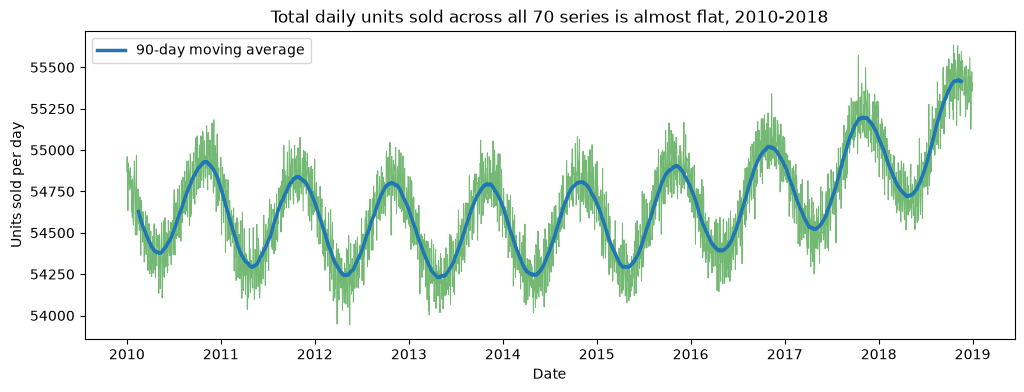

In [41]:

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily_total.index, daily_total.values, linewidth=0.7, color="green", alpha=.55)
ax.plot(daily_total.index, daily_total.rolling(90, center=True).mean(),
         linewidth=2.5, label="90-day moving average")
ax.set_title("Total daily units sold across all 70 series is almost flat, 2010-2018")
ax.set_ylabel("Units sold per day")
ax.set_xlabel("Date")

ax.legend()
save(fig, "daily_total_units_sold")
plt.show()

Year on year percentage change for training data 2010 to 2018

In [42]:
yearly_total = df_train.assign(year=df_train.Date.dt.year).groupby("year").number_sold.sum()

yoy = pd.DataFrame({"total_units": yearly_total, "yoy_pct": yearly_total.pct_change() * 100}).round(2)

print("Year-over-year change 2010 to 2018: "
      f"{(yearly_total.loc[2018] / yearly_total.loc[2010] - 1) * 100:.2f}%")
yoy

Year-over-year change 2010 to 2018: 0.71%


,total_units,yoy_pct
year,,
2010,19951393,NaN
2011,19920275,-0.16
2012,19956937,0.18
2013,19895009,-0.31
2014,19902095,0.04
2015,19926216,0.12
2016,20017834,0.46
2017,20019537,0.01
2018,20093992,0.37


The total grew only **0.7% in nine years**. This could make us think that there is no trend and that we can simply predict the average but That would be wrong, because the total hides what each single series is doing.

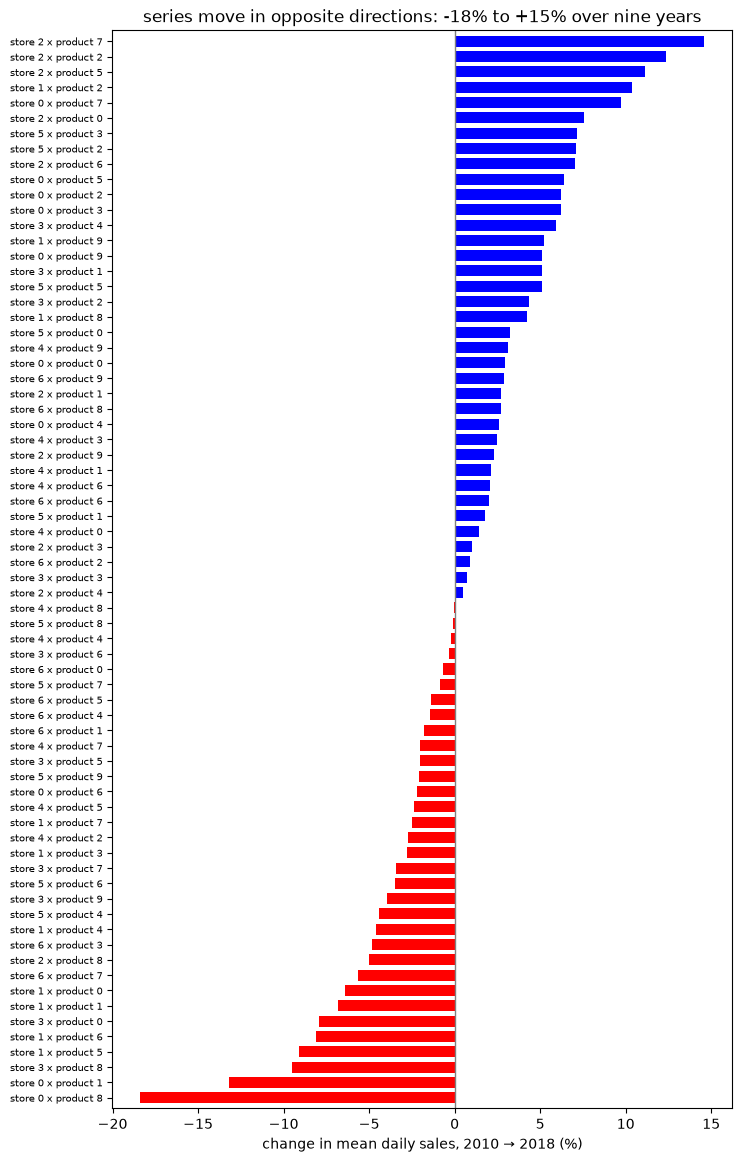

In [43]:
growth = pair_statistics["growth_2010_2018_pct"].sort_values()
  

fig, ax = plt.subplots(figsize=(8, 14))
ax.barh(range(len(growth)), growth.values, color=["red" if v < 0 else "blue" for v in growth.values], height=.72)
ax.set_yticks(range(len(growth)), labels = [f"store {s} x product {p}" for s, p in growth.index], fontsize=7.5)
ax.axvline(0, color="gray", linewidth=1)
ax.set_title("series move in opposite directions: -18% to +15% over nine years")
ax.set_xlabel("change in mean daily sales, 2010 → 2018 (%)")
ax.margins(y=.005)
save(fig, "per_series_growth_2010_2018")
plt.show()

The three pairs that fell the most and the three that grew the most (monthly averages)

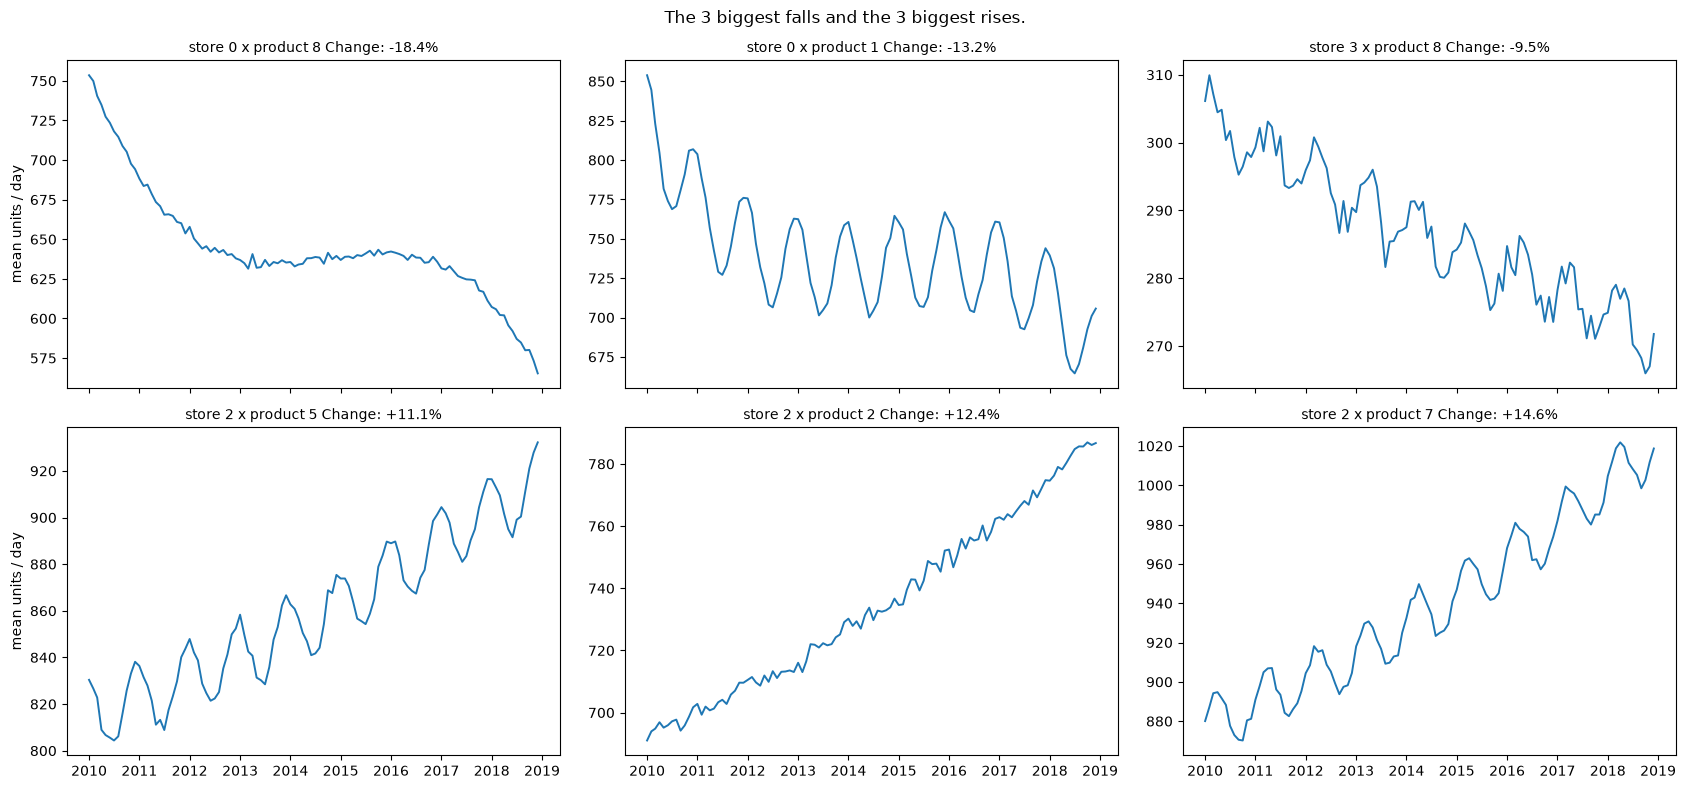

In [44]:
three_worst = list(growth.index[:3])
three_best = list(growth.index[-3:])
extremes = three_worst + three_best

monthly = (train_copy
           .set_index("Date")
           .groupby(["store", "product"])
           .number_sold
           .resample("MS") # month start
           .mean())

fig, axes = plt.subplots(2, 3, figsize=(17, 8), sharex=True)
axes = axes.ravel()

for i, key in enumerate(extremes):
    store, product = key
    one_series = monthly.loc[(store, product)]
    change = growth.loc[key]

    ax = axes[i]
    ax.plot(one_series.index, one_series.values, color="tab:blue", linewidth=1.4)
    ax.set_title(f"store {store} x product {product} Change: {change:+.1f}%", fontsize=10)

axes[0].set_ylabel("mean units / day")
axes[3].set_ylabel("mean units / day")

fig.suptitle("The 3 biggest falls and the 3 biggest rises.", fontsize=12)
fig.tight_layout()
save(fig, "trends_extremes")
plt.show()

### Finding 3: The total looks stable, but individual series behave differently

When we combine all 70 store-product series, total sales increased by only **0.7%** from 2010 to 2018. At first, this makes the overall sales trend look almost unchanged.

However, the individual series show much larger differences. Store 0, product 8 decreased by **18.4%**, while store 2, product 7 increased by **14.6%**. Overall, **33 pairs decreased and 37 increased**. These opposite movements partly cancel each other out when we look only at total sales.

**It means that:**
The model should consider the behavior of each store-product pair instead of only looking at total sales (mostly flat). Different pairs have different trends, so the pair trend can help improve predictions.


## 5. Seasonal patterns

We look at two cycles: the week (day of the week) and the yearly patterns based on the month. They behave very differently.

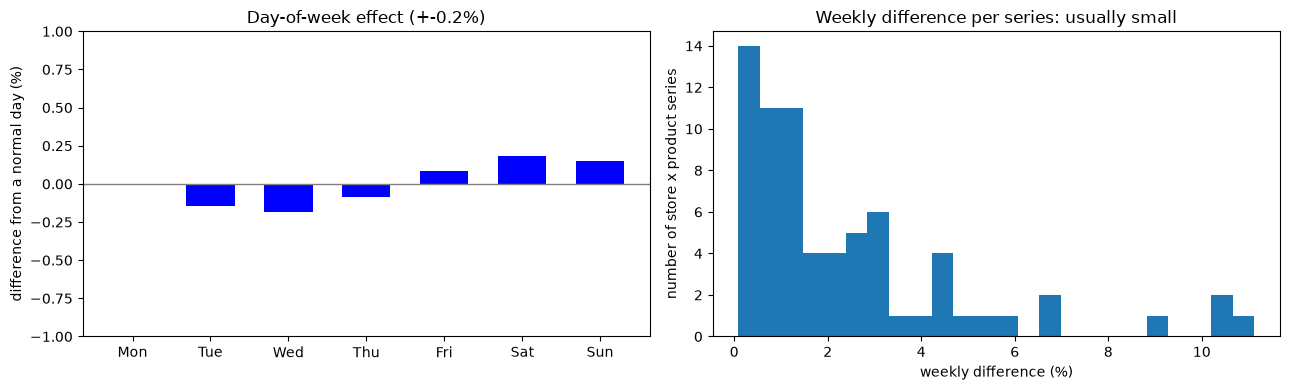

Weekly difference: median 1.33%, max 11.12%


In [45]:
day_of_week_all = train_copy.groupby("day_of_week").number_sold.mean()
day_of_week_all = day_of_week_all / day_of_week_all.mean() * 100           #Average sales on each day of the week, as % of a normal day (100 = normal).


# Ploting the difference from 100, so that 0 means "a normal day".
difference_from_normal = day_of_week_all.values - 100
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))


# Left chart: the weekly pattern, using all pairs together.
axes[0].bar(day_names, difference_from_normal, color="blue", width=.62)
axes[0].axhline(0, color="gray", linewidth=1)
axes[0].set_ylim(-1, 1)
axes[0].set_title("Day-of-week effect (+-0.2%)")
axes[0].set_ylabel("difference from a normal day (%)")


# Right chart: how big the weekly swing is inside each of the 70 pairs.
axes[1].hist(pair_statistics["weekly_difference_pct"], bins=24, color="tab:blue")
axes[1].set_title("Weekly difference per series: usually small")
axes[1].set_xlabel("weekly difference (%)")
axes[1].set_ylabel("number of store x product series")

fig.tight_layout()
save(fig, "weekly_seasonality")
plt.show()

median_swing = pair_statistics["weekly_difference_pct"].median()
biggest_swing = pair_statistics["weekly_difference_pct"].max()
biggest_pair = pair_statistics["weekly_difference_pct"].idxmax()

print(f"Weekly difference: median {median_swing:.2f}%, max {biggest_swing:.2f}%")

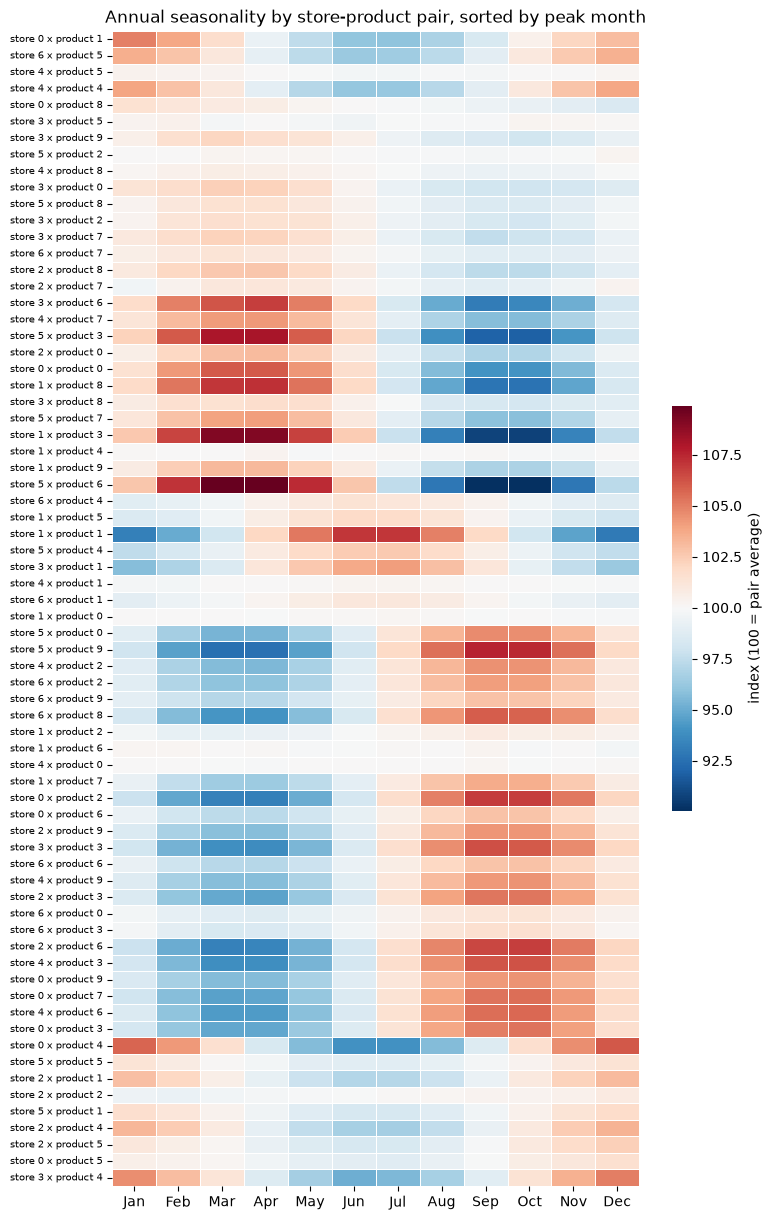

In [46]:
# Find the peak month for each store-product pair
peak_month = month_index.idxmax(axis=1)

# Sort store-product pairs by their peak month
ordered_pairs = peak_month.sort_values().index

# Reorder the monthly index table
month_disp = month_index.loc[ordered_pairs].copy()

month_disp.index = [
    f"store {store} x product {product}"
    for store, product in month_disp.index
]

month_disp.columns = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

# Plot heatmap
fig, ax = plt.subplots(figsize=(8.5, 15))

sns.heatmap(
    month_disp,
    cmap="RdBu_r",
    center=100,
    ax=ax,
    cbar_kws={
        "label": "index (100 = pair average)",
        "shrink": 0.35
    },
    linewidths=0.4,
    linecolor="white"
)

ax.set_title(
    "Annual seasonality by store-product pair, sorted by peak month"
)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="y", labelsize=7.5, rotation=0)

save(fig, "monthly_seasonality_heatmap")
plt.show()

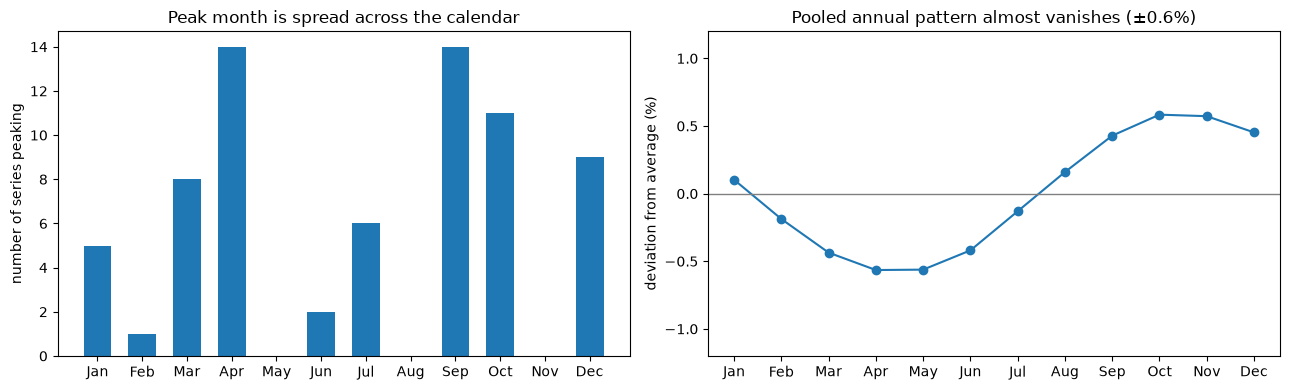

annual difference: median 6.1%, max 19.8%


In [47]:
peak_counts = pair_statistics["peak_month"].value_counts().reindex(range(1, 13), fill_value=0)
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(month_names, peak_counts.values, color="tab:blue", width=.62)
axes[0].set_title("Peak month is spread across the calendar")
axes[0].set_ylabel("number of series peaking")

pooled = train_copy.groupby("month").number_sold.mean()
pooled = pooled / pooled.mean() * 100
axes[1].plot(month_names, pooled.values - 100, color="tab:blue", marker="o")
axes[1].axhline(0, color="gray", linewidth=1)
axes[1].set_ylim(-1.2, 1.2)
axes[1].set_title("Pooled annual pattern almost vanishes (±0.6%)")
axes[1].set_ylabel("deviation from average (%)")
fig.tight_layout()
save(fig, "peak_month_distribution")
plt.show()

print(
    f"annual difference: median {pair_statistics['annual_difference_pct'].median():.1f}%, "
    f"max {pair_statistics['annual_difference_pct'].max():.1f}%"
)

### Finding 4: Yearly seasonality differs across pairs, while weekly seasonality is generally weak

The weekly pattern is small. When all pairs are combined, average sales differ by only about ±0.2% across weekdays. Across the individual store-product pairs, the median difference between the strongest and weakest weekday is about 1.3%. This suggests that weekly seasonality is much weaker than yearly seasonality.

The time of year matters more. The median difference between the strongest and weakest month is about 6.1%, and for some pairs it is close to 20%.

The pairs also peak at different times of the year. Across the 70 series, the peak month occurs in nine different months. Because these seasonal patterns occur at different times, they partly cancel when all series are combined, leaving a pooled monthly pattern of only about ±0.6%.

**What this means for the model is that:**

Annual seasonality should be considered at the store-product level. A separate seasonal model can be fitted for each pair, or a regression model can use month together with store and product information so that different pairs can have different seasonal patterns.

## 6. Differences between stores and products

Here we check one question: if a store sells more than another store, does it sell more by the same
amount for every product?

For example, if store 4 sells 15% more than store 0 for product 1, does it also sell 15% more for
product 2, product 3 and so on. If so, we can describe sales with one number for each store and one
number for each product. If no, some products sell especially well or especially badly in certain
stores. Then the model needs to know each store and product combination, not only the store and the
product on their own.

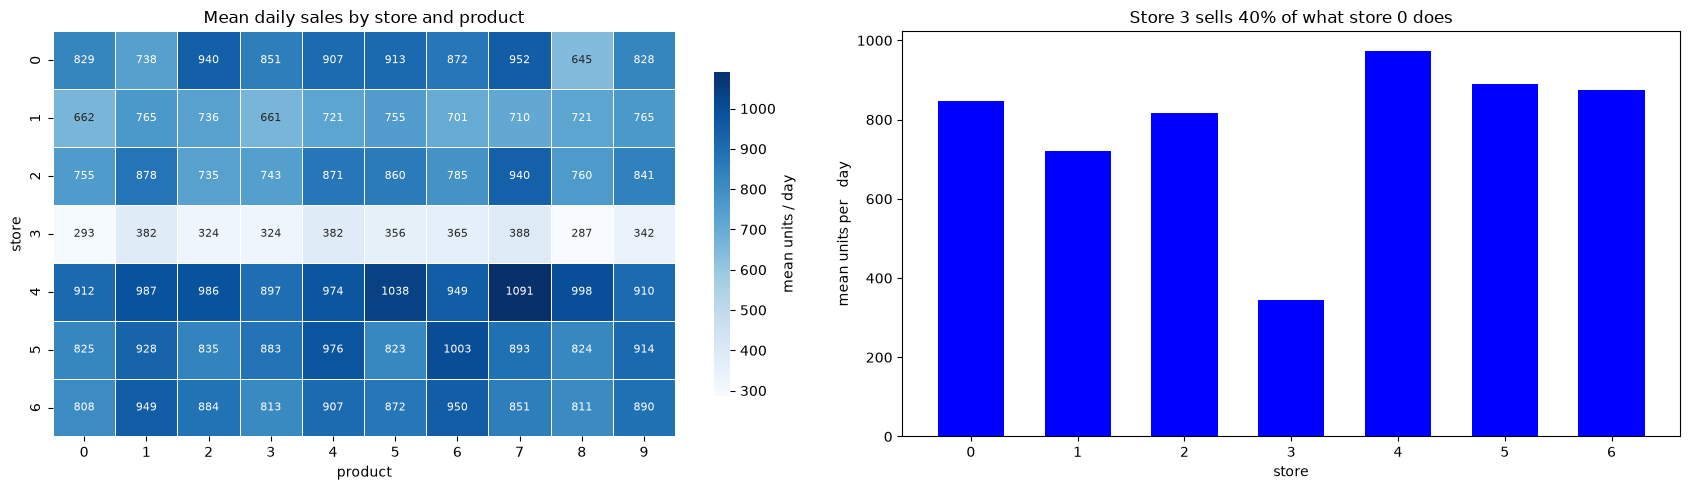

In [48]:
pair_mean = train_copy.pivot_table(index="store", columns="product", values="number_sold", aggfunc="mean")

fig, axes = plt.subplots(1, 2, figsize=(17, 5))

ax = axes[0]
sns.heatmap(pair_mean, cmap="Blues", annot=True, fmt=".0f", annot_kws={"size": 8},
            ax=ax, cbar_kws={"label": "mean units / day", "shrink": .8},
            linewidths=.5, linecolor="white")
ax.set_title("Mean daily sales by store and product")

ax = axes[1]
store_mean = train_copy.groupby("store").number_sold.mean()
ax.bar(store_mean.index.astype(str), store_mean.values, color="blue", width=.62)
ax.set_title("Store 3 sells 40% of what store 0 does")
ax.set_xlabel("store")
ax.set_ylabel("mean units per   day")
fig.tight_layout()
save(fig, "store_product_heatmap")
plt.show()

Separability test: if sales = f(store) x g(product), the store-to-store ratio must be the SAME for every product. Deviation from that is real interaction.

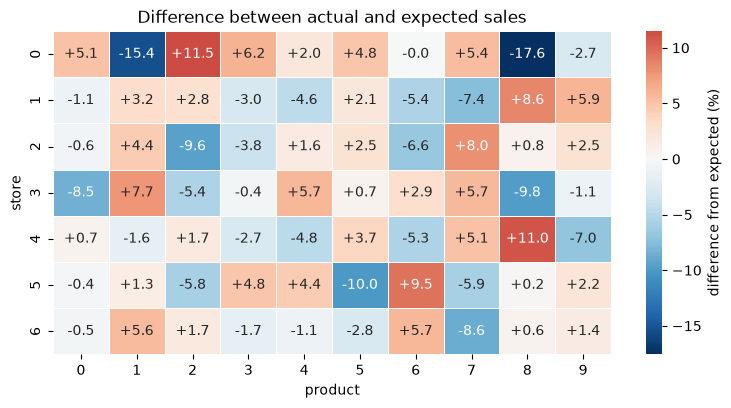

average difference: 4.6%, largest difference: 17.6%


In [49]:
# Average sales by store and by product
store_avg = pair_mean.mean(axis=1)
product_avg = pair_mean.mean(axis=0)
overall_avg = pair_mean.values.mean()

# Expected sales if store and product effects were independent
expected = np.outer(store_avg, product_avg) / overall_avg

# Difference between actual and expected sales
difference = (pair_mean.values / expected - 1) * 100

difference = pd.DataFrame(
    difference,
    index=pair_mean.index,
    columns=pair_mean.columns
)

fig, ax = plt.subplots(figsize=(9, 4.2))

sns.heatmap(
    difference,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt="+.1f",
    ax=ax,
    cbar_kws={"label": "difference from expected (%)"},
    linewidths=.5,
    linecolor="white"
)

ax.set_title("Difference between actual and expected sales")

save(fig, "store_product_interaction")
plt.show()

print(
    f"average difference: {difference.abs().values.mean():.1f}%, "
    f"largest difference: {difference.abs().values.max():.1f}%"
)

Different sales levels for each store but similar shape

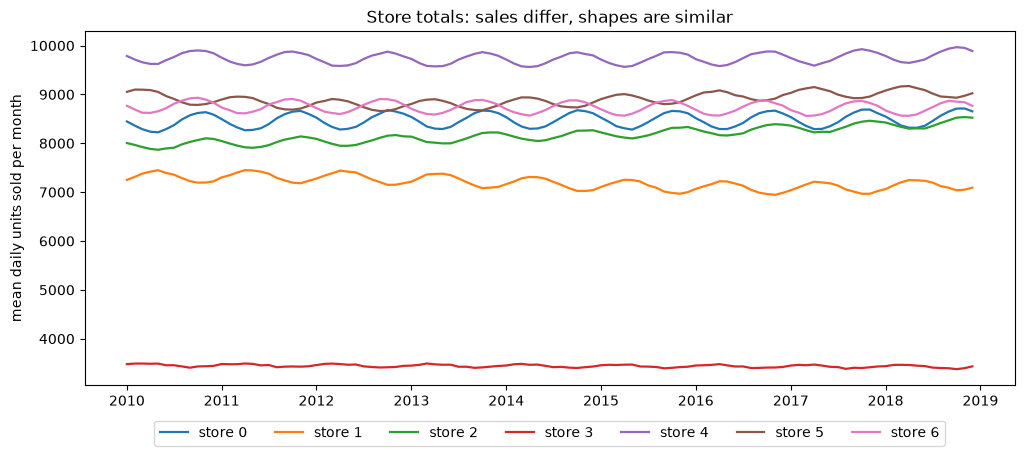

In [50]:
store_daily = (df_train.groupby(["Date", "store"]).number_sold.sum()
               .unstack("store").resample("MS").mean())

fig, ax = plt.subplots(figsize=(12, 4.6))
for i, store in enumerate(store_daily.columns):
    ax.plot(store_daily.index, store_daily[store], color=f"C{i}",
            linewidth=1.6, label=f"store {store}")
ax.set_title("Store totals: sales differ, shapes are similar")
ax.set_ylabel("mean daily units sold per month")
ax.legend(ncols=7, loc="upper center", bbox_to_anchor=(.5, -.08))
save(fig, "store_totals_over_time")
plt.show()

## Finding 5: Sales differ across stores, products, and store-product combinations

Stores have very different average sales levels. For example, Store 3 sells only about 40% of what Store 0 sells on average.

The difference between stores is not the same for every product. Some store-product pairs sell more than expected from their separate store and product averages, while others sell less. The average absolute difference is 4.6%, and the largest is 17.6%.

What this means for the model: store and product should both be included. The exact store-product combination also contains useful information, so the regression model can include a pair feature.

## 7. Summary: what this means for the hybrid model

| # | Finding | What we do in the model |
|---|---|---|
| 1 | The data is complete and clean. The 2019 test data includes the real sales values. | Keep 2019 for final testing and use 2018 for validation and tuning. |
| 2 | The pairs have very different sales levels, from about 287 to 1,091 units per day. Most pairs have relatively low variability around their average level. | The model needs to account for the different sales levels of each pair. |
| 3 | Total sales changed by only about +0.7%, but individual pairs changed between about -18% and +15%. | Model sales at the store-product level so that each pair can have its own trend. |
| 4 | Annual seasonality is stronger than weekly seasonality, and different pairs peak in different months. | Include annual seasonal information at the pair level. |
| 5 | Sales differ across stores products, and specific store-product combinations. | Include store, product, and the exact store-product pair as model features. |